- {Notebook} [test-on testdataset+qwenemdding+llama](https://www.kaggle.com/code/yangjiahua/test-on-testdataset-qwenemdding-llama)
  - qwen 2.5 14b 모델 사용
- {Notebook} [test-on testdataset+qwenemdding+llama lr](https://www.kaggle.com/code/kishanvavdara/test-on-testdataset-qwenemdding-llama-lr)
  - public score 0.916
- {Model} [lora_14B_GPTQ_1epoch_r32](https://www.kaggle.com/models/yangjiahua/lora_14b_gptq_1epoch_r32)

위 노트북 따라가 보기

- {comment} [comment](https://www.kaggle.com/code/yangjiahua/test-on-testdataset-qwenemdding-llama/comments#3274096)

> 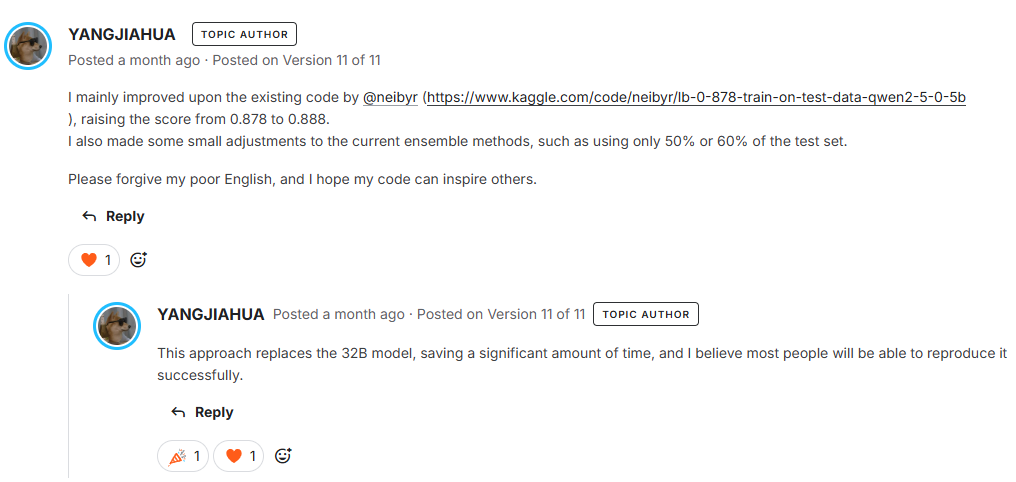

**Version History**

- v2: offline install
- v1: dependency manager

# 1. Environment Setup
- {Notebook} [jigsaw-packages2](https://www.kaggle.com/code/hiranorm/jigsaw-packages2)

In [ ]:
!uv pip install --system --no-index --find-links='/kaggle/input/jigsaw-packages2/whls/' 'trl==0.21.0' 'optimum==1.27.0' 'auto-gptq==0.7.1' 'bitsandbytes==0.46.1' 'deepspeed==0.17.4' 'logits-processor-zoo==0.2.1' 'vllm==0.10.0'
!uv pip install --system --no-index --find-links='/kaggle/input/jigsaw-packages2/whls/' 'triton==3.2.0'
!uv pip install --system --no-index --find-links='/kaggle/input/jigsaw-packages2/whls/' 'clean-text'
!uv pip install --system --no-index -U --no-deps --find-links='/kaggle/input/jigsaw-packages2/whls/' 'peft' 'accelerate' 'datasets'

In [ ]:
import os
import pandas as pd
from logits_processor_zoo.vllm import MultipleChoiceLogitsProcessor
import torch
import vllm
import numpy as np
from vllm.lora.request import LoRARequest
import argparse
from scipy.special import softmax

In [ ]:
MODEL_NAME = "/kaggle/input/qwen2.5/transformers/14b-instruct-gptq-int4/1"
LORA_PATH = "/kaggle/input/lora_14b_gptq_1epoch_r32/keras/default/1"

os.environ["VLLM_USE_V1"] = "0"

# 2. Prepare Model

In [ ]:
llm = vllm.LLM(
    MODEL_NAME,
    # quantization='awq',
    quantization='gptq',
    tensor_parallel_size=torch.cuda.device_count(),
    gpu_memory_utilization=0.98,
    trust_remote_code=True,
    dtype="half",
    enforce_eager=True,
    max_model_len=4096,
    disable_log_stats=True,
    enable_prefix_caching=True,
    enable_lora=True,
    max_lora_rank=32
)
llm

In [ ]:
tokenizer = llm.get_tokenizer()
tokenizer

In [ ]:
mclp = MultipleChoiceLogitsProcessor(tokenizer, choices=['Yes','No'])
mclp

# 3. Prepare Prompt

In [ ]:
df = pd.read_csv("/kaggle/input/jigsaw-agile-community-rules/test.csv")
df_train= pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/train.csv')
unlabelled_df= pd.read_csv('/kaggle/input/jigsaw-2m-reddit-unlabelled/reddit-removal-log.csv')
print(df.shape)
df.head()

In [ ]:
SYS_PROMPT = """
You are given a comment on reddit. Your task is to classify if it violates the given rule. Only respond Yes/No.
"""

In [ ]:
prompts = []
for i, row in df.iterrows():
    text = f"""
r/{row.subreddit}
Rule: {row.rule}

1) {row.positive_example_1}
Violation: Yes

2) {row.positive_example_2}
Violation: Yes

3) {row.negative_example_1}
Violation: No

4) {row.negative_example_2}
Violation: No

5) {row.body}
"""
    
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": text}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False,
    ) + "Answer:"
    prompts.append(prompt)

df["prompt"] = prompts
df.shape

In [ ]:
print(df.iloc[0]['prompt'])

# 4. Inference

In [ ]:
outputs = llm.generate(
    prompts,
    vllm.SamplingParams(
        skip_special_tokens=True,
        max_tokens=1,
        logits_processors=[mclp],
        logprobs=2,
    ),
    use_tqdm=True,
    lora_request=LoRARequest("default", 1, LORA_PATH)
)
len(outputs)

In [ ]:
outputs[0]

In [ ]:
logprobs = [
    {lp.decoded_token: lp.logprob for lp in out.outputs[0].logprobs[0].values()}
    for out in outputs
]
len(logprobs)

In [ ]:
logprobs[0]

# 5. Submit

In [ ]:
logit_matrix = pd.DataFrame(logprobs)[['Yes','No']]
print(logit_matrix.shape)
logit_matrix.head()

In [ ]:
df = pd.concat([df, logit_matrix], axis=1)
print(df.shape)
df.head()

In [ ]:
df[['Yes',"No"]].head()

In [ ]:
df[['Yes',"No"]] = df[['Yes',"No"]].apply(lambda x: softmax(x.values), axis=1, result_type="expand")
df[['Yes',"No"]].head()

In [ ]:
df["pred"] = df["Yes"]
df['rule_violation'] = df["pred"]
df[['row_id', 'rule_violation']].to_csv("submission.csv",index=False)

In [ ]:
print(df[['row_id', 'rule_violation']].shape)
df[['row_id', 'rule_violation']].head()

In [ ]:
!head submission.csv